## Problem 1: Block Matching and 3D Filtering:

In [1]:
import sys
import os

In [2]:
sys.path.append(os.path.abspath('./bm3d-4.0.3'))

In [3]:
!pip install bm4d


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import numpy as np
import bm3d
import matplotlib.pyplot as plt
import skimage
from skimage.metrics import mean_squared_error

### 1. Comparing MSE Performance

In [5]:
clean_img = skimage.img_as_float(skimage.io.imread('./dataset/cameramanclean.png', as_gray=True))
noisy_img = skimage.img_as_float(skimage.io.imread('./dataset/cameramannoisy.png', as_gray=True))

true_variance = mean_squared_error(clean_img, noisy_img)
true_std = np.sqrt(true_variance)
print(f"True Variance of the noise: {true_variance:.6f}")

True Variance of the noise: 0.025800


In [6]:
# 1st Stage: only hard thresholding
denoised_stage1 = bm3d.bm3d(noisy_img, sigma_psd=true_std, stage_arg=bm3d.BM3DStages.HARD_THRESHOLDING)
mse_stage1 = mean_squared_error(clean_img, denoised_stage1)

# 2nd Stage: hard thresholding + Wiener filtering
denoised_stage2 = bm3d.bm3d(noisy_img, sigma_psd=true_std, stage_arg=bm3d.BM3DStages.ALL_STAGES)
mse_stage2 = mean_squared_error(clean_img, denoised_stage2)

print(f"MSE after 1st stage: {mse_stage1:.6f}")
print(f"MSE after 2nd stage: {mse_stage2:.6f}")

MSE after 1st stage: 0.008453
MSE after 2nd stage: 0.007516


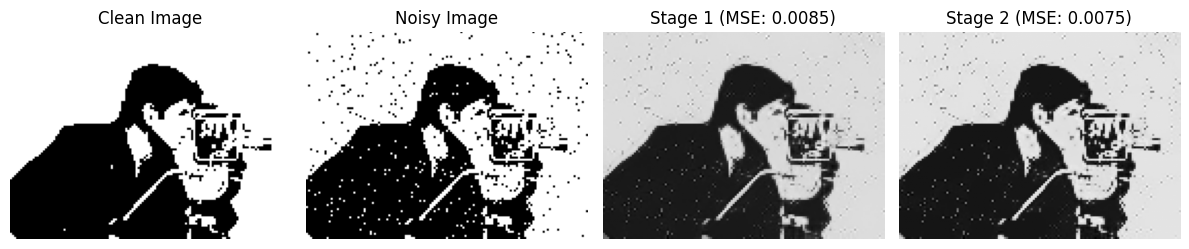

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(12, 6))
axes[0].imshow(clean_img, cmap='gray')
axes[0].set_title("Clean Image")
axes[1].imshow(noisy_img, cmap='gray')
axes[1].set_title("Noisy Image")
axes[2].imshow(denoised_stage1, cmap='gray')
axes[2].set_title(f"Stage 1 (MSE: {mse_stage1:.4f})")
axes[3].imshow(denoised_stage2, cmap='gray')
axes[3].set_title(f"Stage 2 (MSE: {mse_stage2:.4f})")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

### 2. MSE vs Noise Variance

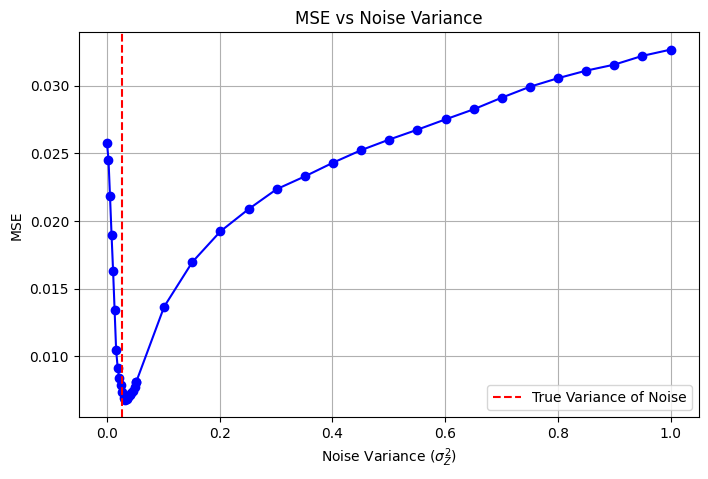

In [ ]:
sigma_sq_list = np.linspace(0, true_variance * 2, 20)
sigma_sq_list = np.concatenate((sigma_sq_list, np.linspace(true_variance * 2, 1, 20)))
mse_values = []

for sigma_sq in sigma_sq_list:
    sigma = np.sqrt(sigma_sq)
    denoised_img = bm3d.bm3d(noisy_img, sigma_psd=sigma, stage_arg=bm3d.BM3DStages.ALL_STAGES)
    mse = mean_squared_error(clean_img, denoised_img)
    mse_values.append(mse)

plt.figure(figsize=(8, 5))
plt.plot(sigma_sq_list, mse_values, marker='o', linestyle='-', color='b')
plt.axvline(true_variance, color='r', linestyle='--', label='True Variance of Noise')
plt.xlabel("Noise Variance ($\sigma_Z^2$)")
plt.ylabel("MSE")
plt.title("MSE vs Noise Variance")
plt.legend()
plt.grid(True)
plt.show()

### Replacing Wiener Filter with Hard Thresholding

In [9]:
# The Python  bm3d library is a "wrapper". It doesn't have a simple flag that says "Do Stage 2, but use HT instead of Wiener."

# If you pass an image as a pilot, it automatically uses the Wiener Filter.
# If you choose the Hard Thresholding mode, it automatically looks for blocks in the input image.
# To "trick" it into doing Stage 1 filtering (HT) using Stage 2 grouping (Pilot), 
# we have to separate the grouping result from the filtering logic:

# Extract the "Map": We run a dummy pass on the Stage 1 image (est_stage1) just to get the list of matches (the blockmatches).
# Apply to Noisy Data: we call the function on the Noisy image but pass that pre-calculated "Map" through the blockmatches argument. 
# This tells the function: "Don't bother looking for blocks in the noisy image; 
# just use these exact coordinates we found in the cleaner image, then apply Hard Thresholding to the noisy data."

In [ ]:
# get pilot image from Stage 1
denoised_stage1 = bm3d.bm3d(noisy_img, sigma_psd=true_std, stage_arg=bm3d.BM3DStages.HARD_THRESHOLDING)
# get the block match coords
_, matches_from_pilot = bm3d.bm3d(denoised_stage1, sigma_psd=0, stage_arg=bm3d.BM3DStages.HARD_THRESHOLDING, blockmatches=(True, False))
# apply hard thresholding using the block matches
denoised_stage2_ht = bm3d.bm3d(noisy_img, sigma_psd=true_std, stage_arg=bm3d.BM3DStages.HARD_THRESHOLDING, blockmatches=matches_from_pilot)

mse_stage2_ht = mean_squared_error(clean_img, denoised_stage2_ht)
print(f"MSE after Stage 2 (Wiener Filtering)      : {mse_stage2:.6f}")
print(f"MSE after Stage 2 (Hard Thresholding Est) : {mse_stage2_ht:.6f}")

MSE after Stage 2 (Wiener Filtering)      : 0.007516
MSE after Stage 2 (Hard Thresholding Est) : 0.008736
